In [53]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score

from sklearn.model_selection import train_test_split

In [2]:
df=pd.read_csv('shop_smart_ecommerce.csv')

In [3]:
df.sample(8)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
9175,0,0.000000,0,0.0,12,201.333333,0.016667,0.035714,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
3024,1,97.000000,0,0.0,4,59.000000,0.000000,0.013333,0.000000,0.0,May,2,2,6,6,New_Visitor,False,False
9861,0,0.000000,0,0.0,5,73.000000,0.120000,0.160000,0.000000,0.0,Nov,2,2,2,3,Returning_Visitor,False,False
8874,17,218.741707,4,808.5,74,3591.744196,0.019767,0.015610,0.000000,0.0,Nov,3,2,1,2,Returning_Visitor,False,False
3922,1,72.000000,1,6.0,84,1212.030303,0.005102,0.021451,0.000000,0.0,May,2,2,5,6,Returning_Visitor,False,False
8362,0,0.000000,0,0.0,26,532.000000,0.030769,0.044231,0.000000,0.0,Nov,2,2,1,1,Returning_Visitor,False,False
9954,0,0.000000,0,0.0,26,548.267857,0.024000,0.046667,0.000000,0.0,Nov,1,2,6,2,Returning_Visitor,False,False
4681,16,313.866667,3,153.5,156,3899.001328,0.000170,0.011253,1.534836,0.0,May,2,2,2,4,Returning_Visitor,False,False


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [5]:
num_df = df.select_dtypes(include='number')
corr_matrix = num_df.corr()
corr_matrix

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
Administrative,1.000000,0.601583,0.376850,0.255848,0.431119,0.373939,-0.223563,-0.316483,0.098990,-0.094778,-0.006347,-0.025035,-0.005487,-0.033561
Administrative_Duration,0.601583,1.000000,0.302710,0.238031,0.289087,0.355422,-0.144170,-0.205798,0.067608,-0.073304,-0.007343,-0.015392,-0.005561,-0.014376
Informational,0.376850,0.302710,1.000000,0.618955,0.374164,0.387505,-0.116114,-0.163666,0.048632,-0.048219,-0.009527,-0.038235,-0.029169,-0.034491
Informational_Duration,0.255848,0.238031,0.618955,1.000000,0.280046,0.347364,-0.074067,-0.105276,0.030861,-0.030577,-0.009579,-0.019285,-0.027144,-0.024675
ProductRelated,0.431119,0.289087,0.374164,0.280046,1.000000,0.860927,-0.204578,-0.292526,0.056282,-0.023958,0.004290,-0.013146,-0.038122,-0.043064
ProductRelated_Duration,0.373939,0.355422,0.387505,0.347364,0.860927,1.000000,-0.184541,-0.251984,0.052823,-0.036380,0.002976,-0.007380,-0.033091,-0.036377
BounceRates,-0.223563,-0.144170,-0.116114,-0.074067,-0.204578,-0.184541,1.000000,0.913004,-0.119386,0.072702,0.023823,-0.015772,-0.006485,0.078286
ExitRates,-0.316483,-0.205798,-0.163666,-0.105276,-0.292526,-0.251984,0.913004,1.000000,-0.174498,0.102242,0.014567,-0.004442,-0.008907,0.078616
PageValues,0.098990,0.067608,0.048632,0.030861,0.056282,0.052823,-0.119386,-0.174498,1.000000,-0.063541,0.018508,0.045592,0.011315,0.012532
SpecialDay,-0.094778,-0.073304,-0.048219,-0.030577,-0.023958,-0.036380,0.072702,0.102242,-0.063541,1.000000,0.012652,0.003499,-0.016098,0.052301


In [6]:
df['Month']

0        Feb
1        Feb
2        Feb
3        Feb
4        Feb
        ... 
12325    Dec
12326    Nov
12327    Nov
12328    Nov
12329    Nov
Name: Month, Length: 12330, dtype: object

In [7]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [8]:
df['Month']=df['Month'].str.strip().str.title()

In [9]:
df['Month'].unique()

array(['Feb', 'Mar', 'May', 'Oct', 'June', 'Jul', 'Aug', 'Nov', 'Sep',
       'Dec'], dtype=object)

In [11]:
Month_map={
   'Jan':1,'Feb':2,'Mar':3,'April':4,'May':5,'June':6,'Jul':7,'Aug':8,'Sep':9,'Oct':10,'Nov':11,'Dec':12
}
df['Month']=df['Month'].map(Month_map)

In [13]:
df['Month_sin']=np.sin(2*np.pi*(df['Month'])/12)
df['Month_cos']=np.cos(2*np.pi*(df['Month'])/12)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  int64  
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [21]:
df=pd.get_dummies(df,columns=['VisitorType'],drop_first=True)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12330 non-null  int64  
 1   Administrative_Duration        12330 non-null  float64
 2   Informational                  12330 non-null  int64  
 3   Informational_Duration         12330 non-null  float64
 4   ProductRelated                 12330 non-null  int64  
 5   ProductRelated_Duration        12330 non-null  float64
 6   BounceRates                    12330 non-null  float64
 7   ExitRates                      12330 non-null  float64
 8   PageValues                     12330 non-null  float64
 9   SpecialDay                     12330 non-null  float64
 10  Month                          12330 non-null  int64  
 11  OperatingSystems               12330 non-null  int64  
 12  Browser                        12330 non-null 

In [23]:
df['VisitorType_Other']=df['VisitorType_Other'].astype('int')
df['VisitorType_Returning_Visitor']=df['VisitorType_Returning_Visitor'].astype('int')
df['Weekend']=df['Weekend'].astype('int')
df['Revenue']=df['Revenue'].astype('int')

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12330 non-null  int64  
 1   Administrative_Duration        12330 non-null  float64
 2   Informational                  12330 non-null  int64  
 3   Informational_Duration         12330 non-null  float64
 4   ProductRelated                 12330 non-null  int64  
 5   ProductRelated_Duration        12330 non-null  float64
 6   BounceRates                    12330 non-null  float64
 7   ExitRates                      12330 non-null  float64
 8   PageValues                     12330 non-null  float64
 9   SpecialDay                     12330 non-null  float64
 10  Month                          12330 non-null  int64  
 11  OperatingSystems               12330 non-null  int64  
 12  Browser                        12330 non-null 

In [57]:
X=df.drop(columns=['Revenue'])
y=df['Revenue']

In [58]:
x_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y
)

In [59]:
from sklearn.tree import DecisionTreeClassifier
max_depth=[2,3,4,5,6,7,8,9,10]
for depth in max_depth:
    model=DecisionTreeClassifier(max_depth=depth)
    model.fit(x_train,y_train)
    y_pred = model.predict(X_test)
    f1=f1_score(y_test,y_pred)
    print(f"for depth={depth}, f1={f1}")

for depth=2, f1=0.5293132328308208
for depth=3, f1=0.6476683937823834
for depth=4, f1=0.6666666666666666
for depth=5, f1=0.6072507552870091
for depth=6, f1=0.6111908177905309
for depth=7, f1=0.6306818181818182
for depth=8, f1=0.6091794158553546
for depth=9, f1=0.5855728429985856
for depth=10, f1=0.580110497237569


In [60]:
min_samples_split=[5,10,15,20,25,30,35]
for split in min_samples_split:
    model=DecisionTreeClassifier(max_depth=4,min_samples_split=split)
    model.fit(x_train,y_train)
    y_pred = model.predict(X_test)
    f1=f1_score(y_test,y_pred)
    print(f"for split={split}, f1={f1}")

for split=5, f1=0.6666666666666666
for split=10, f1=0.6666666666666666
for split=15, f1=0.6666666666666666
for split=20, f1=0.6666666666666666
for split=25, f1=0.6666666666666666
for split=30, f1=0.6666666666666666
for split=35, f1=0.6666666666666666


In [36]:
#post pruning

In [61]:
full_tree=DecisionTreeClassifier(random_state=42)
full_tree.fit(x_train,y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [62]:
path=full_tree.cost_complexity_pruning_path(x_train,y_train)
ccp_alphas=path.ccp_alphas
print(ccp_alphas)

[0.00000000e+00 5.02200294e-05 6.08272506e-05 6.33617194e-05
 6.43674610e-05 6.53329729e-05 6.59766475e-05 6.60839266e-05
 6.61165767e-05 6.65460519e-05 6.66339209e-05 6.66965467e-05
 6.69359702e-05 6.72039931e-05 6.72319815e-05 7.60340633e-05
 7.95129649e-05 8.44822925e-05 9.01144453e-05 9.01144453e-05
 9.01144453e-05 9.01144453e-05 9.12408759e-05 9.12408759e-05
 9.12408759e-05 9.12408759e-05 9.12408759e-05 9.15650836e-05
 9.21625009e-05 9.21625009e-05 9.29305218e-05 9.29305218e-05
 9.35803856e-05 9.35803856e-05 9.35803856e-05 9.41374117e-05
 9.41374117e-05 9.41374117e-05 9.41374117e-05 9.46201676e-05
 9.46201676e-05 9.50425791e-05 9.50425791e-05 9.53557957e-05
 9.55993429e-05 9.57465982e-05 9.57465982e-05 9.63098135e-05
 9.63098135e-05 9.65511914e-05 9.67706260e-05 9.67706260e-05
 9.68224027e-05 9.69308015e-05 9.70951418e-05 9.72269452e-05
 9.73266883e-05 9.74031137e-05 9.74795683e-05 9.76239825e-05
 9.79994593e-05 9.85626746e-05 9.85626746e-05 9.87294805e-05
 9.89358895e-05 9.907468

In [63]:
tree=[]
for alpha in ccp_alphas:
    model=DecisionTreeClassifier(random_state=42,ccp_alpha=alpha)
    model.fit(x_train,y_train)
    tree.append((model,alpha))

In [66]:
best_alpha=0
best_f1=0
for model,alpha in tree:
    y_pred = model.predict(X_test)
    curr_f1=f1_score(y_test,y_pred)
    if curr_f1>best_f1:
        best_f1=curr_f1
        best_alpha=alpha
    

In [67]:
best_f1

0.6666666666666666

In [68]:
best_model=model=DecisionTreeClassifier(max_depth=4,min_samples_split=10,ccp_alpha=best_alpha)
best_model.fit(x_train,y_train)
y_pred = model.predict(X_test)
f1=f1_score(y_test,y_pred)

In [69]:
f1

0.6666666666666666

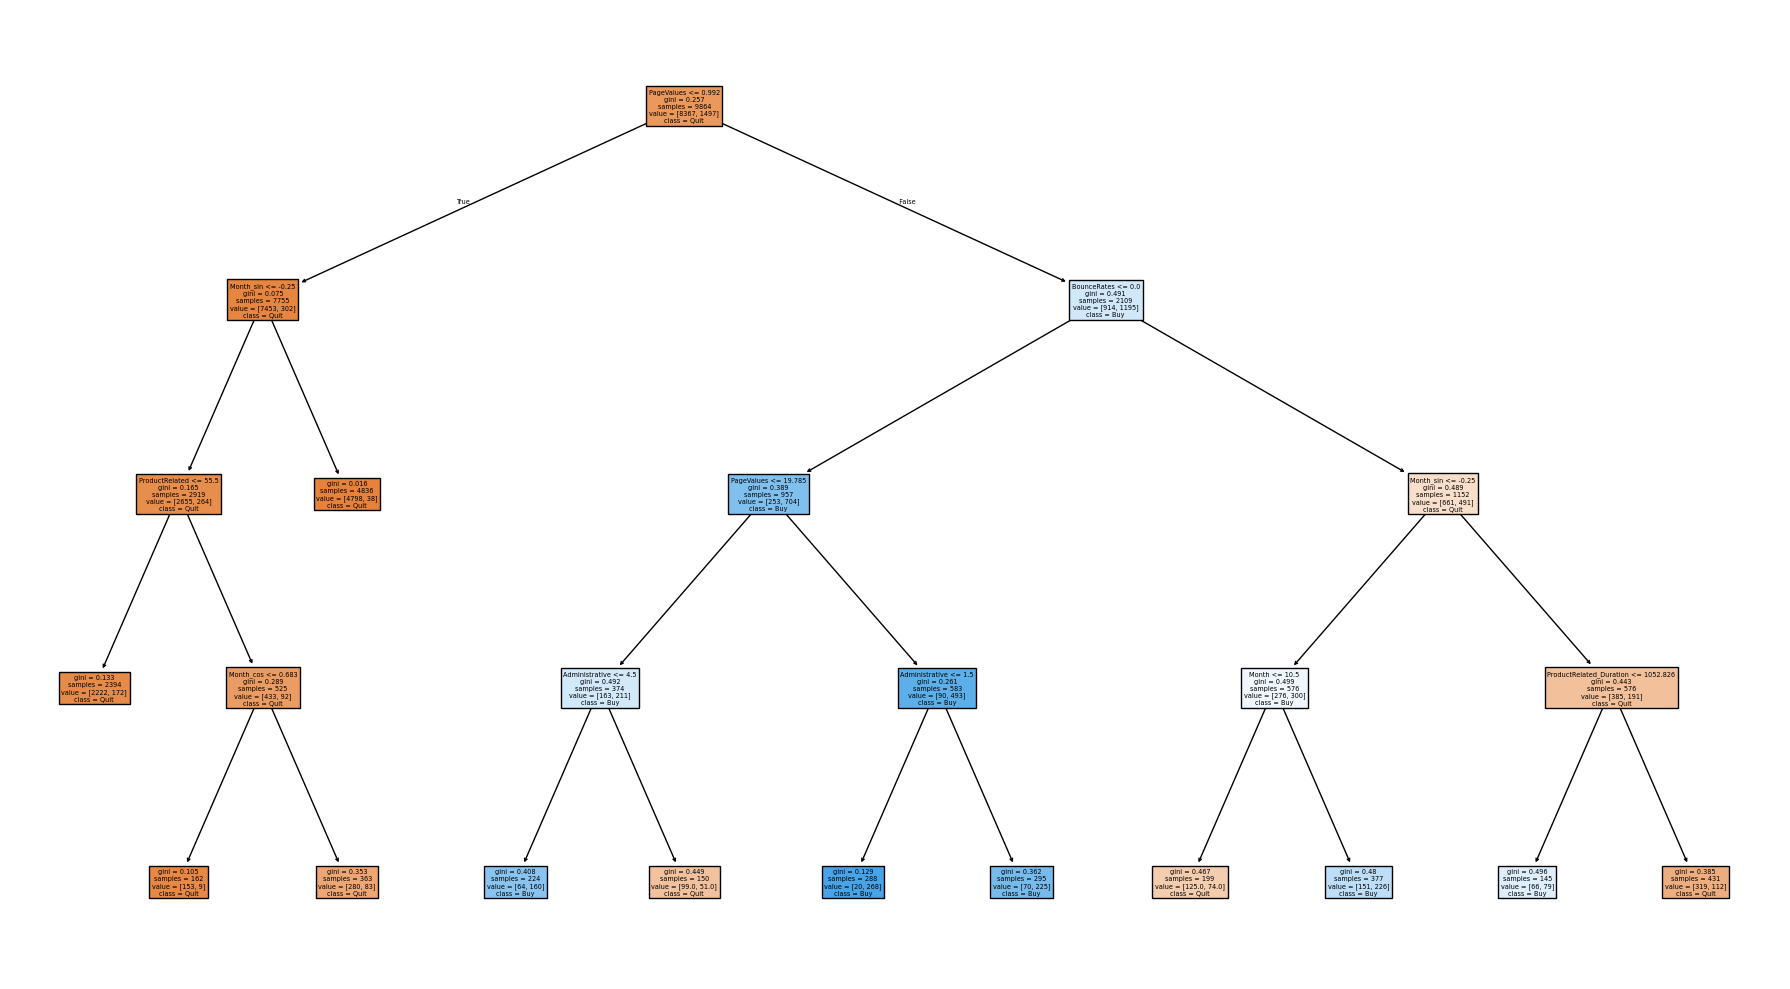

In [52]:
from sklearn.tree import plot_tree
plt.figure(figsize=(18,10))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=['Quit','Buy'],
    filled=True
)
plt.tight_layout()
plt.show()